# Baseline Tree Models — Wildfire Binary Classification

Uses the same HF Hub data as the PatchTST+DLA notebook.
- **XGBoost** (GPU via `device='cuda'`)
- **CatBoost** (GPU via `task_type='GPU'`)
- **LightGBM** (GPU via `device='gpu'`)

The `[N, T=4, F=25]` arrays are flattened to `[N, 100]` before fitting.
Threshold tuning on validation PR-AUC matches the deep-model eval protocol.

In [4]:
!pip -q install huggingface_hub scikit-learn xgboost catboost lightgbm

In [5]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from huggingface_hub import hf_hub_download

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, precision_score,
    recall_score, f1_score, confusion_matrix,
)

import xgboost as xgb
import catboost as cb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

WORK_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('/tmp')
ARTIFACT_DIR = WORK_DIR / 'Wildfire_baseline'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Artifact dir:', ARTIFACT_DIR)

Artifact dir: /tmp/Wildfire_baseline


In [6]:
# -------------------------
# Download from Hugging Face
# -------------------------
HF_X_REPO = 'NagrajMG/WildFire-X'
HF_Y_REPO = 'NagrajMG/WildFire-Y'
HF_TOKEN  = os.getenv('HF_TOKEN', None)
CACHE_DIR = WORK_DIR / 'hf_cache'

# Try to read token from Kaggle secrets if running there
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret('HUGGINGFACE_TOKEN')
    print('HF token loaded from Kaggle secrets')
except Exception:
    pass

SPLITS = ['train', 'val', 'test']
paths = {}
for split in SPLITS:
    paths[f'x_{split}'] = hf_hub_download(
        repo_id=HF_X_REPO, filename=f'FEATURES_{split}.csv',
        repo_type='dataset', token=HF_TOKEN, cache_dir=CACHE_DIR,
    )
    paths[f'y_{split}'] = hf_hub_download(
        repo_id=HF_Y_REPO, filename=f'LABELS_{split}.csv',
        repo_type='dataset', token=HF_TOKEN, cache_dir=CACHE_DIR,
    )
    print(f'{split}: x={paths[f"x_{split}"].split("/")[-1]}  y={paths[f"y_{split}"].split("/")[-1]}')

FEATURES_train.csv:   0%|          | 0.00/47.1M [00:00<?, ?B/s]

LABELS_train.csv: 0.00B [00:00, ?B/s]

train: x=FEATURES_train.csv  y=LABELS_train.csv


FEATURES_val.csv:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

LABELS_val.csv: 0.00B [00:00, ?B/s]

val: x=FEATURES_val.csv  y=LABELS_val.csv


FEATURES_test.csv: 0.00B [00:00, ?B/s]

LABELS_test.csv: 0.00B [00:00, ?B/s]

test: x=FEATURES_test.csv  y=LABELS_test.csv


In [8]:
# -------------------------
# Load + align X/Y CSVs
# actual columns: target_date, row, col, window_id, <features>
# labels:         target_date, row, col, label, type_class, split
# -------------------------
EXPECTED_WINDOWS = 4
X_META_COLS = ['target_date', 'row', 'col', 'window_id']
SAMPLE_KEY  = ['target_date', 'row', 'col']

def load_split(x_path, y_path, split_name):
    x_df = pd.read_csv(x_path)
    y_df = pd.read_csv(y_path)

    feature_cols = [c for c in x_df.columns if c not in X_META_COLS]

    # Sort X by sample key + window, then reshape
    x_df = x_df.sort_values(SAMPLE_KEY + ['window_id']).reset_index(drop=True)

    # Build unique sample keys in the order they appear after sorting
    keys_df   = x_df[SAMPLE_KEY].drop_duplicates().reset_index(drop=True)
    n_samples = len(keys_df)
    n_feat    = len(feature_cols)

    X = x_df[feature_cols].values.reshape(n_samples, EXPECTED_WINDOWS, n_feat).astype(np.float32)

    # Align labels via merge on sample key
    y_merged  = keys_df.merge(y_df[SAMPLE_KEY + ['label']], on=SAMPLE_KEY, how='left')
    y_aligned = y_merged['label'].fillna(0).values.astype(np.int32)

    print(f'{split_name}  X:{X.shape}  y:{y_aligned.shape}  pos={y_aligned.sum()}')
    return X, y_aligned, feature_cols

X_train, y_train, feature_cols = load_split(paths['x_train'], paths['y_train'], 'train')
X_val,   y_val,   _            = load_split(paths['x_val'],   paths['y_val'],   'val')
X_test,  y_test,  _            = load_split(paths['x_test'],  paths['y_test'],  'test')

N_FEAT = len(feature_cols)
print('features:', N_FEAT)

train  X:(47530, 4, 25)  y:(47530,)  pos=23765
val  X:(10290, 4, 25)  y:(10290,)  pos=5145
test  X:(1890, 4, 25)  y:(1890,)  pos=945
features: 25


In [9]:
# -------------------------
# Feature engineering: flatten + hand-crafted temporal stats
# -------------------------
def make_flat_features(X):
    """[N,T,F] -> [N, T*F + 4*F] (raw windows + mean/std/last/trend)"""
    N, T, F = X.shape
    flat = X.reshape(N, T * F)                        # raw
    mu   = X.mean(axis=1)                             # [N,F]
    sd   = X.std(axis=1)                              # [N,F]
    last = X[:, -1, :]                                # [N,F] most recent window
    trend = X[:, -1, :] - X[:, 0, :]                 # [N,F] latest - earliest
    return np.concatenate([flat, mu, sd, last, trend], axis=1).astype(np.float32)

X_train_flat = make_flat_features(X_train)
X_val_flat   = make_flat_features(X_val)
X_test_flat  = make_flat_features(X_test)

# Normalise (tree models are invariant but helps for consistent baselines)
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat).astype(np.float32)
X_val_flat   = scaler.transform(X_val_flat).astype(np.float32)
X_test_flat  = scaler.transform(X_test_flat).astype(np.float32)

# Build feature names
win_names    = [f'w{t+1}_{f}' for t in range(4) for f in feature_cols]
extra_names  = (
    [f'mean_{f}' for f in feature_cols] +
    [f'std_{f}'  for f in feature_cols] +
    [f'last_{f}' for f in feature_cols] +
    [f'trend_{f}' for f in feature_cols]
)
all_feat_names = win_names + extra_names
print('Total features after engineering:', len(all_feat_names))

Total features after engineering: 200


In [10]:
# -------------------------
# Shared evaluation helpers
# -------------------------
def iou_score(tp, fp, fn):
    return tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0

def metrics_at_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return dict(
        threshold=thr, pr_auc=average_precision_score(y_true, y_prob),
        precision=prec, recall=rec, f1=f1,
        iou=iou_score(tp, fp, fn), specificity=spec,
        tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn),
    )

def tune_threshold(y_val, val_prob, grid=np.linspace(0.05, 0.95, 19)):
    best_thr, best_f1 = 0.5, -1
    for thr in grid:
        f1 = f1_score(y_val, (val_prob >= thr).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(thr)
    return best_thr

def print_metrics(title, m):
    print(f'\n{title}')
    print('-' * len(title))
    print(f'Threshold   : {m["threshold"]:.4f}')
    print(f'PR AUC      : {m["pr_auc"]:.4f}')
    print(f'Precision   : {m["precision"]:.4f}')
    print(f'Recall      : {m["recall"]:.4f}')
    print(f'F1          : {m["f1"]:.4f}')
    print(f'IoU         : {m["iou"]:.4f}')
    print(f'Specificity : {m["specificity"]:.4f}')
    print(f'TP/FP/FN/TN : {m["tp"]}/{m["fp"]}/{m["fn"]}/{m["tn"]}')

def evaluate_model(name, val_prob, test_prob):
    best_thr = tune_threshold(y_val, val_prob)
    val_m    = metrics_at_threshold(y_val,  val_prob,  best_thr)
    test_m   = metrics_at_threshold(y_test, test_prob, best_thr)
    test_05  = metrics_at_threshold(y_test, test_prob, 0.5)
    print(f'\n{'='*20} {name} {'='*20}')
    print_metrics(f'Val @ best thr ({best_thr:.2f})', val_m)
    print_metrics('Test @ best thr', test_m)
    print_metrics('Test @ 0.5', test_05)
    return {'name': name, 'best_thr': best_thr,
            'val': val_m, 'test_best': test_m, 'test_05': test_05}

In [11]:
# -------------------------
# XGBoost (GPU)
# -------------------------
scale_pos = float((y_train == 0).sum()) / float((y_train == 1).sum())

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=scale_pos,
    tree_method='hist',
    device='cuda',           # GPU on Ubuntu + NVIDIA
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=SEED,
    verbosity=1,
)

xgb_model.fit(
    X_train_flat, y_train,
    eval_set=[(X_val_flat, y_val)],
    verbose=50,
)

xgb_val_prob  = xgb_model.predict_proba(X_val_flat)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test_flat)[:, 1]
xgb_res = evaluate_model('XGBoost', xgb_val_prob, xgb_test_prob)

[0]	validation_0-aucpr:0.76803
[50]	validation_0-aucpr:0.84413
[100]	validation_0-aucpr:0.84724
[150]	validation_0-aucpr:0.84955
[173]	validation_0-aucpr:0.84956


/home/dell/code/wildfire_data/.venv/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [01:55:11] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



==================== XGBoost ====================

Val @ best thr (0.35)
---------------------
Threshold   : 0.3500
PR AUC      : 0.8501
Precision   : 0.7147
Recall      : 0.8303
F1          : 0.7682
IoU         : 0.6236
Specificity : 0.6686
TP/FP/FN/TN : 4272/1705/873/3440

Test @ best thr
---------------
Threshold   : 0.3500
PR AUC      : 0.8749
Precision   : 0.7726
Recall      : 0.7947
F1          : 0.7835
IoU         : 0.6441
Specificity : 0.7661
TP/FP/FN/TN : 751/221/194/724

Test @ 0.5
----------
Threshold   : 0.5000
PR AUC      : 0.8749
Precision   : 0.8633
Recall      : 0.7153
F1          : 0.7824
IoU         : 0.6426
Specificity : 0.8868
TP/FP/FN/TN : 676/107/269/838


In [12]:
# -------------------------
# CatBoost (GPU)
# -------------------------
cat_model = cb.CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='PRAUC',
    task_type='GPU',          # GPU on Ubuntu + NVIDIA
    devices='0',
    early_stopping_rounds=30,
    random_seed=SEED,
    verbose=50,
)

cat_model.fit(
    X_train_flat, y_train,
    eval_set=(X_val_flat, y_val),
    use_best_model=True,
)

cat_val_prob  = cat_model.predict_proba(X_val_flat)[:, 1]
cat_test_prob = cat_model.predict_proba(X_test_flat)[:, 1]
cat_res = evaluate_model('CatBoost', cat_val_prob, cat_test_prob)

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.7879572	test: 0.7426602	best: 0.7426602 (0)	total: 76.4ms	remaining: 1m 16s
50:	learn: 0.8659222	test: 0.8310783	best: 0.8310783 (50)	total: 3.36s	remaining: 1m 2s
100:	learn: 0.8818873	test: 0.8426590	best: 0.8426590 (100)	total: 7.07s	remaining: 1m 2s
150:	learn: 0.8895131	test: 0.8459418	best: 0.8460569 (147)	total: 10.8s	remaining: 1m
200:	learn: 0.8947330	test: 0.8487207	best: 0.8488231 (199)	total: 13.8s	remaining: 55.1s
250:	learn: 0.8989180	test: 0.8486185	best: 0.8494263 (236)	total: 24s	remaining: 1m 11s
bestTest = 0.8494262545
bestIteration = 236
Shrink model to first 237 iterations.

==================== CatBoost ====================

Val @ best thr (0.35)
---------------------
Threshold   : 0.3500
PR AUC      : 0.8494
Precision   : 0.7074
Recall      : 0.8519
F1          : 0.7729
IoU         : 0.6299
Specificity : 0.6476
TP/FP/FN/TN : 4383/1813/762/3332

Test @ best thr
---------------
Threshold   : 0.3500
PR AUC      : 0.8689
Precision   : 0.7435
Recall      :

In [13]:
# -------------------------
# LightGBM (GPU)
# -------------------------
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    scale_pos_weight=scale_pos,
    device='gpu',            # GPU on Ubuntu + NVIDIA
    gpu_platform_id=0,
    gpu_device_id=0,
    objective='binary',
    metric='average_precision',
    random_state=SEED,
    verbose=-1,
)

lgb_model.fit(
    X_train_flat, y_train,
    eval_set=[(X_val_flat, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True),
        lgb.log_evaluation(period=50),
    ],
)

lgb_val_prob  = lgb_model.predict_proba(X_val_flat)[:, 1]
lgb_test_prob = lgb_model.predict_proba(X_test_flat)[:, 1]
lgb_res = evaluate_model('LightGBM', lgb_val_prob, lgb_test_prob)

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 30 rounds
[50]	valid_0's average_precision: 0.83971
[100]	valid_0's average_precision: 0.848252
[150]	valid_0's average_precision: 0.850777
[200]	valid_0's average_precision: 0.851056
Early stopping, best iteration is:
[176]	valid_0's average_precision: 0.851523

==================== LightGBM ====================

Val @ best thr (0.35)
---------------------
Threshold   : 0.3500
PR AUC      : 0.8515
Precision   : 0.7202
Recall      : 0.8270
F1          : 0.7699
IoU         : 0.6259
Specificity : 0.6787
TP/FP/FN/TN : 4255/1653/890/3492

Test @ best thr
---------------
Threshold   : 0.3500
PR AUC      : 0.8729
Precision   : 0.7854
Recall      : 0.7862
F1          : 0.7858
IoU         : 0.6472
Specificity : 0.7852
TP/FP/FN/TN : 743/203/202/742

Test @ 0.5
----------
Threshold   : 0.5000
PR AUC      : 0.8729
Precision   : 0.8662
Recall      : 0.7122
F1          : 0.7816
IoU         : 0.6416
Specificity : 0.8899
TP/FP/FN/TN : 673/104/272/841

/home/dell/code/wildfire_data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/dell/code/wildfire_data/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
# -------------------------
# Comparison table
# -------------------------
rows = []
for res in [xgb_res, cat_res, lgb_res]:
    rows.append({
        'model'       : res['name'],
        'best_thr'    : res['best_thr'],
        'val_pr_auc'  : res['val']['pr_auc'],
        'val_f1'      : res['val']['f1'],
        'test_pr_auc' : res['test_best']['pr_auc'],
        'test_f1'     : res['test_best']['f1'],
        'test_iou'    : res['test_best']['iou'],
        'test_prec'   : res['test_best']['precision'],
        'test_recall' : res['test_best']['recall'],
        'test_spec'   : res['test_best']['specificity'],
    })

compare_df = pd.DataFrame(rows).set_index('model')
display(compare_df.round(4))

# Reference from PatchTST+DLA (test @ best thr)
ref = dict(pr_auc=0.8350, f1=0.7378, iou=0.5846, precision=0.6893, recall=0.7937, specificity=0.6423)
print('\nPatchTST+DLA reference (test @ 0.30):')
print(ref)

,best_thr,val_pr_auc,val_f1,test_pr_auc,test_f1,test_iou,test_prec,test_recall,test_spec
model,,,,,,,,,
XGBoost,0.35,0.8501,0.7682,0.8749,0.7835,0.6441,0.7726,0.7947,0.7661
CatBoost,0.35,0.8494,0.7729,0.8689,0.7795,0.6386,0.7435,0.8190,0.7175
LightGBM,0.35,0.8515,0.7699,0.8729,0.7858,0.6472,0.7854,0.7862,0.7852



PatchTST+DLA reference (test @ 0.30):
{'pr_auc': 0.835, 'f1': 0.7378, 'iou': 0.5846, 'precision': 0.6893, 'recall': 0.7937, 'specificity': 0.6423}


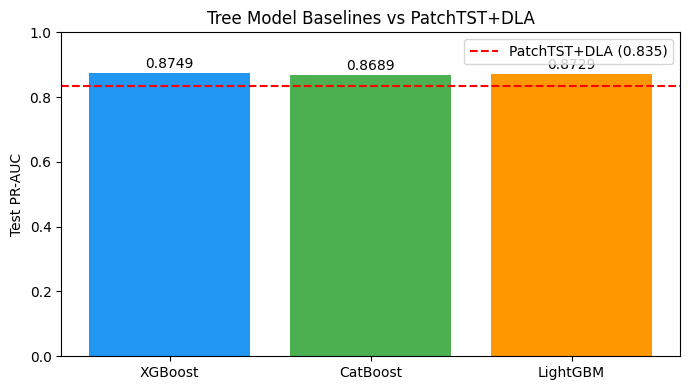

In [15]:
# -------------------------
# PR-AUC bar chart
# -------------------------
models = [r['name'] for r in [xgb_res, cat_res, lgb_res]]
test_prauc = [r['test_best']['pr_auc'] for r in [xgb_res, cat_res, lgb_res]]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, test_prauc, color=['#2196F3', '#4CAF50', '#FF9800'])
plt.axhline(0.8350, color='red', linestyle='--', label='PatchTST+DLA (0.835)')
for bar, val in zip(bars, test_prauc):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.4f}', ha='center', va='bottom')
plt.ylim(0, 1)
plt.ylabel('Test PR-AUC')
plt.title('Tree Model Baselines vs PatchTST+DLA')
plt.legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'baseline_prauc_comparison.png', dpi=150)
plt.show()

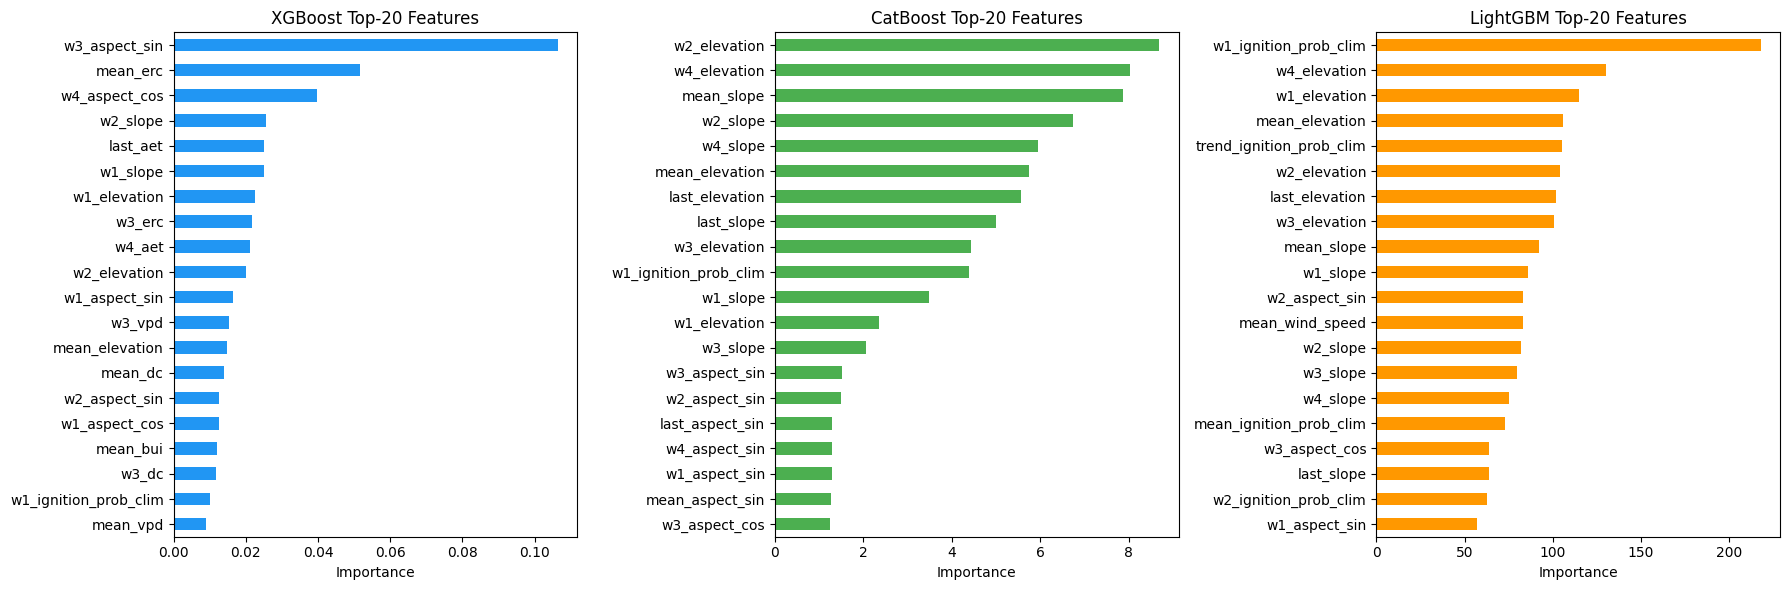

In [16]:
# -------------------------
# Feature importance plots
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=all_feat_names).nlargest(20)
xgb_imp[::-1].plot.barh(ax=axes[0], color='#2196F3')
axes[0].set_title('XGBoost Top-20 Features')
axes[0].set_xlabel('Importance')

# CatBoost
cat_imp = pd.Series(cat_model.get_feature_importance(), index=all_feat_names).nlargest(20)
cat_imp[::-1].plot.barh(ax=axes[1], color='#4CAF50')
axes[1].set_title('CatBoost Top-20 Features')
axes[1].set_xlabel('Importance')

# LightGBM
lgb_imp = pd.Series(lgb_model.feature_importances_, index=all_feat_names).nlargest(20)
lgb_imp[::-1].plot.barh(ax=axes[2], color='#FF9800')
axes[2].set_title('LightGBM Top-20 Features')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'baseline_feature_importance.png', dpi=150)
plt.show()

In [17]:
# -------------------------
# Save models + metrics
# -------------------------
import pickle

xgb_model.save_model(str(ARTIFACT_DIR / 'xgboost_model.json'))
cat_model.save_model(str(ARTIFACT_DIR / 'catboost_model.cbm'))
lgb_model.booster_.save_model(str(ARTIFACT_DIR / 'lightgbm_model.txt'))

with open(ARTIFACT_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

all_results = {
    'feature_count': len(all_feat_names),
    'models': [xgb_res, cat_res, lgb_res],
    'patchtst_dla_reference': {'test_pr_auc': 0.835, 'test_f1': 0.7378},
}
with open(ARTIFACT_DIR / 'baseline_metrics.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('Saved to:', ARTIFACT_DIR)
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(' ', p.name)

Saved to: /tmp/Wildfire_baseline
  baseline_feature_importance.png
  baseline_metrics.json
  baseline_prauc_comparison.png
  catboost_model.cbm
  lightgbm_model.txt
  scaler.pkl
  xgboost_model.json
